In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
from dadapy.metric_comparisons import MetricComparisons
from scipy.stats import rankdata
import pickle

import scienceplots
plt.style.use(['science','notebook'])
import matplotlib
matplotlib.rcParams.update({'font.size': 16})

In [2]:
from scipy.spatial.distance import pdist, squareform

def nns_index_array(data, metric="euclidean", maxk=1):
    """
    Computes the indices of the k nearest neighbors to each point.

    Args:
        data (np.ndarray or list(list(float))): dataset of shape (N,D), with N points and D features
        metric (str, default="euclidean"): name of the distance employed
        maxk (int, default=1): number of nearest neighbors considered in the Information Imbalance calculation

    Returns:
        NNs (np.ndarray): array of shape (N,k). The ij-th element is the index of the j-th nearest 
                          neighbor to point i.
    """
    N = data.shape[0]

    pairwise_dist = squareform(pdist(data, metric=metric))
    pairwise_dist = pairwise_dist.astype('float')

    rank_matrix = rankdata(pairwise_dist, method='average', axis=1)
    
    NNs = np.zeros((N, maxk+1), dtype=int)
    for i in np.arange(N):
        NNs[i, :] = np.argpartition(rank_matrix[i], np.arange(maxk+1))[:maxk+1]
    return np.array(NNs)

In [3]:
genes_df = pd.read_csv("./data/gene.yyy")
times_df = pd.read_csv("./data/time.yyy")
print(genes_df.shape,times_df.shape)

(228, 3970) (3969, 2)


Visualize datasets

In [4]:
genes_df.T

,0,1,2,3,4,5,6,7,8,9,...,218,219,220,221,222,223,224,225,226,227
Unnamed: 0,CALML6,HTR6,PTAFR,PTGER3,PTGFR,PRKACB,MCOLN2,MCOLN3,NGF,CASQ2,...,ITPKC,CALM3,SLC8A2,GRIN2D,SPHK2,HRC,PRKCG,P2RX6,PDGFB,CACNA1I
EC2-AAACCTGAGGATGCGT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.693147,0.0
EC2-AAAGCAAAGGTGTGGT,0.0,0.0,0.0,0.693147,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.693147,1.386294,0.0,0.0,0.0,1.386294,0.0,0.0,0.693147
EC2-AAAGCAACAGCTATTG,0.0,0.0,0.0,0.0,0.0,0.693147,0.0,0.0,0.0,0.0,...,0.0,1.098612,1.098612,0.0,0.0,0.0,0.693147,0.0,0.693147,0.0
EC2-AAATGCCAGAAGGTTT,0.0,0.0,0.0,0.693147,0.0,0.693147,0.0,0.0,0.0,0.693147,...,0.0,0.0,0.0,0.0,0.693147,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EC10-TTTGGTTCAAAGGTGC,0.0,0.0,0.0,0.0,0.0,0.693147,0.0,0.0,0.0,0.0,...,0.0,0.693147,0.693147,0.0,0.0,0.0,0.693147,0.0,0.0,0.0
EC10-TTTGGTTTCATCACCC,0.0,0.0,0.0,0.0,0.0,0.693147,0.0,0.0,0.0,0.0,...,0.0,0.693147,0.693147,0.0,0.0,0.0,0.0,0.0,0.0,0.693147
EC10-TTTGTCAAGAATAGGG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EC10-TTTGTCAAGACGACGT,0.0,0.0,0.0,0.0,0.0,0.693147,0.0,0.0,0.0,0.0,...,0.0,0.693147,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.693147


In [5]:
times_df

,Sample,Calcium Signaling Pseudotime
0,EC1-TGATTTCGTACAGCAG,1.700983
1,EC1-CACTCCACAACGCACC,13.145695
2,EC1-GGCCGATTCAACTCTT,3.424308
3,EC2-GAGTCCGCAAGTAATG,5.243402
4,EC1-TACAGTGGTAGAGGAA,8.186124
...,...,...
3964,EC10-GGAAAGCCATACTACG,9.191953
3965,EC9-CACAGGCGTTGGTGGA,14.693694
3966,EC10-GCAAACTAGCGTGAAC,13.426085
3967,EC8-CCACTACGTCCAACTA,23.574981


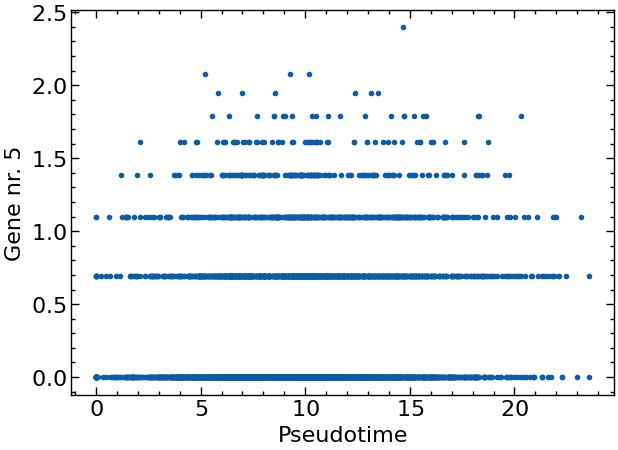

In [6]:
# plot one specific gene before ordering the points in the same manner
i_gene = 5

plt.figure(figsize=(7,5))
plt.plot(times_df['Calcium Signaling Pseudotime'], genes_df.T.iloc[1:,i_gene], '.')
plt.xlabel("Pseudotime")
plt.ylabel(f"Gene nr. {i_gene}")
plt.show()

Sort pseudotimes

In [7]:
times_df = times_df.sort_values(by=['Calcium Signaling Pseudotime'])
times_df

,Sample,Calcium Signaling Pseudotime
917,EC1-CTTCTCTAGTGAAGAG,0.000000
741,EC1-GCGCGATTCTCTTATG,0.000000
846,EC1-CAAGTTGAGCTAGTCT,0.000000
1106,EC1-GCAGCCACAGTACACT,0.000000
376,EC1-GCTTCCAGTGAGGCTA,0.000000
...,...,...
2763,EC8-GACTACATCCACGCAG,22.458712
2262,EC7-AACCGCGCAGACGCTC,22.971278
3204,EC8-CATCGGGGTTTCGCTC,23.200408
3523,EC9-CTTGGCTGTTCTGAAC,23.574981


After sorting:



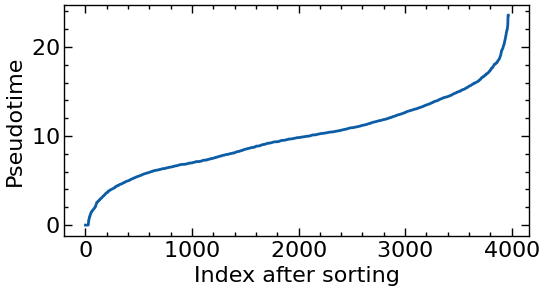

In [8]:
print("After sorting:\n")

plt.figure(figsize=(6,3))
plt.plot(times_df['Calcium Signaling Pseudotime'].values)
plt.xlabel("Index after sorting")
plt.ylabel("Pseudotime")
plt.show()

Reorder points in gene dataset according to labels in time dataset (re-ordered according to pseudotime)

In [9]:
labels_points = times_df['Sample'].values.astype(str)
print(labels_points.shape)

genes_df = genes_df[np.append(['Unnamed: 0'],labels_points)]
print(genes_df.shape)
genes_df

(3969,)
(228, 3970)


,Unnamed: 0,EC1-CTTCTCTAGTGAAGAG,EC1-GCGCGATTCTCTTATG,EC1-CAAGTTGAGCTAGTCT,EC1-GCAGCCACAGTACACT,EC1-GCTTCCAGTGAGGCTA,EC1-TAAGCGTTCATTCACT,EC1-ACTTTCATCTGGTTCC,EC1-GAATAAGAGCCACGCT,EC1-ACGATGTGTTAAGGGC,...,EC8-GGAATAACATAAAGGT,EC8-CGATGGCGTGTATGGG,EC8-CGTAGGCTCACTTCAT,EC8-CCTTTCTAGTACATGA,EC8-TTCGGTCGTGTCAATC,EC8-GACTACATCCACGCAG,EC7-AACCGCGCAGACGCTC,EC8-CATCGGGGTTTCGCTC,EC9-CTTGGCTGTTCTGAAC,EC8-CCACTACGTCCAACTA
0,CALML6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0
1,HTR6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0
2,PTAFR,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.693147,...,0.000000,0.000000,0.0,0.0,0.000000,0.693147,0.0,0.0,0.000000,0.0
3,PTGER3,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0
4,PTGFR,0.000000,0.693147,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.693147,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,HRC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0
224,PRKCG,0.693147,0.000000,0.693147,0.693147,0.693147,0.000000,0.0,0.0,0.693147,...,0.693147,0.693147,0.0,0.0,0.693147,0.000000,0.0,0.0,0.000000,0.0
225,P2RX6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,0.693147,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0
226,PDGFB,0.693147,0.000000,0.000000,0.693147,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0


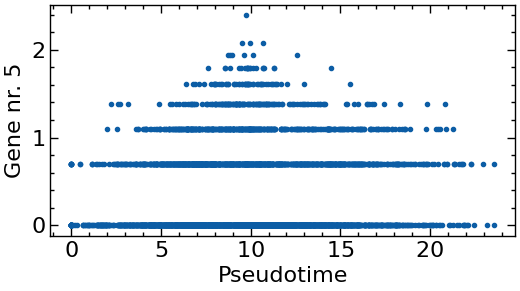

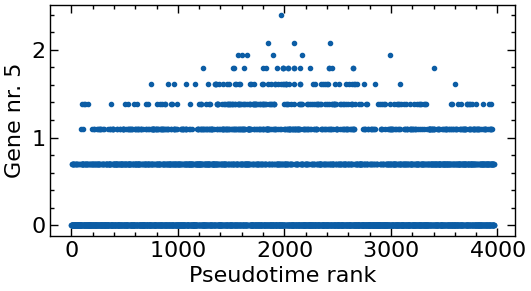

In [10]:
# plot one specific gene after ordering the points according to pseudotime
i_gene = 5

# pseudotime along x axis
plt.figure(figsize=(6,3))
plt.plot(times_df['Calcium Signaling Pseudotime'].values,genes_df.T.iloc[1:,i_gene], '.') #times_df[],
plt.xlabel("Pseudotime")
plt.ylabel(f"Gene nr. {i_gene}")
plt.show()

# psudotime rank along x axis (this way equally spaced points, useful for next moving average)
plt.figure(figsize=(6,3))
plt.plot(np.arange(len(times_df['Calcium Signaling Pseudotime'].values)), genes_df.T.iloc[1:,i_gene], '.') #times_df[],
plt.xlabel("Pseudotime rank")
plt.ylabel(f"Gene nr. {i_gene}")
plt.show()


In [13]:
# extract numpy arrays from pandas dataframes
times = times_df['Calcium Signaling Pseudotime'].to_numpy()
genes = (genes_df.T).iloc[1:,:].to_numpy(dtype=float)
print(times.shape, genes.shape)

# extract gene names for plots
genes_names = (genes_df.T).iloc[0,:].to_numpy(dtype=str)
print(genes_names.shape)

(3969,) (3969, 228)
(228,)


## Introduce noise to break degeneracy in the two spaces

In [14]:
# add noise to break neighbor degeneracies (both in gene and pseudotime spaces)
times += np.random.normal(loc=0., scale=1e-6, size=times.shape)
genes += np.random.normal(loc=0., scale=1e-6, size=genes.shape)

### Try to plot "trajectories" for gene expressions

In [15]:
def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

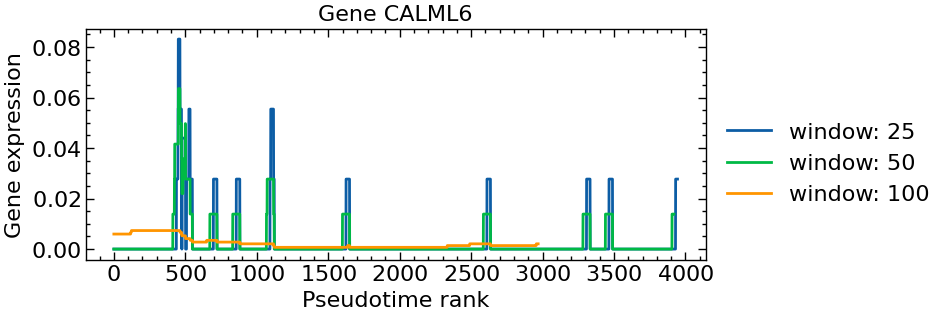

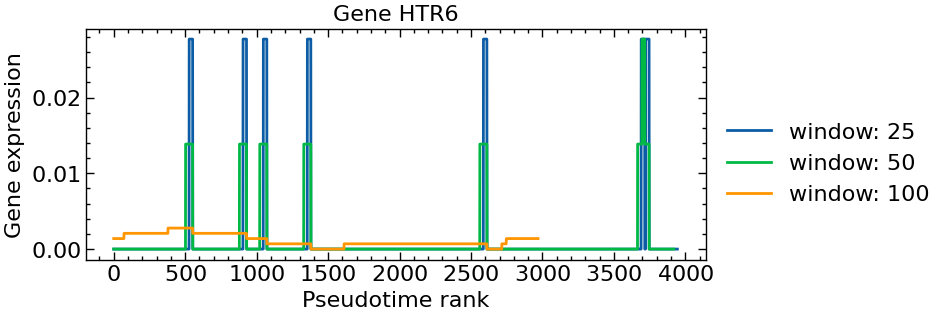

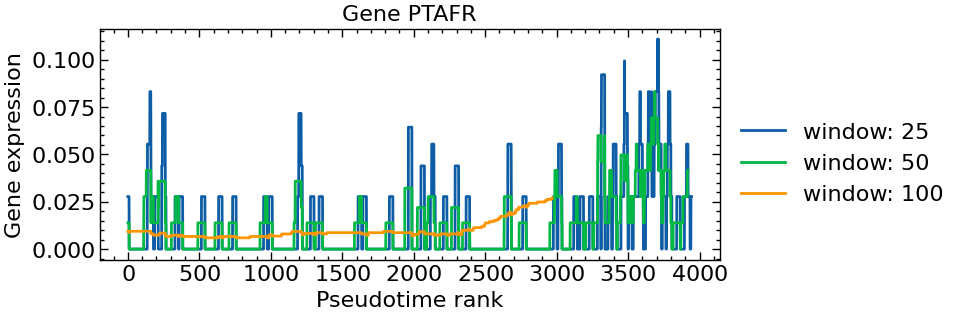

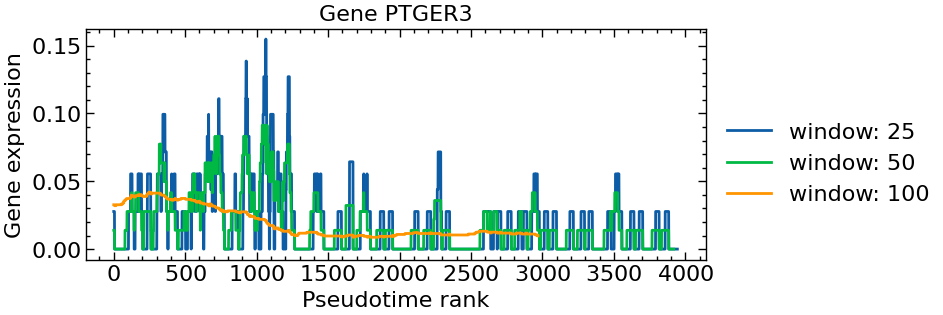

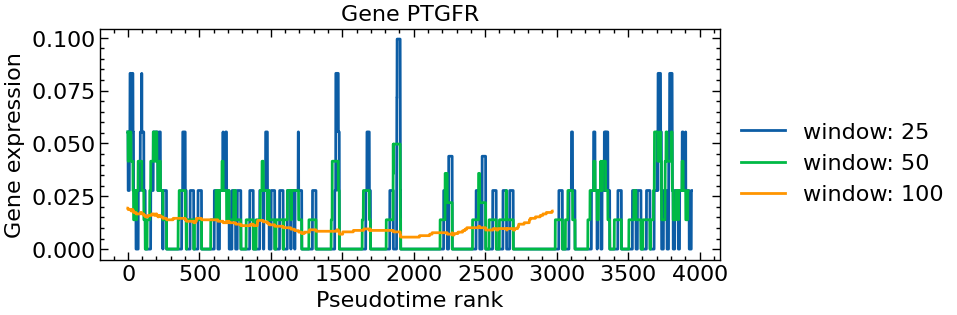

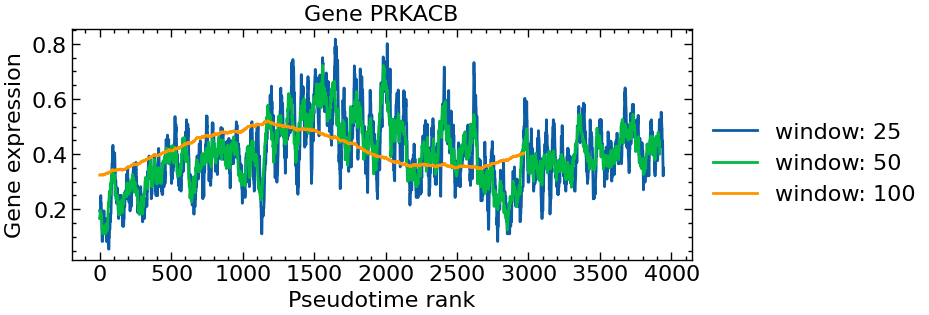

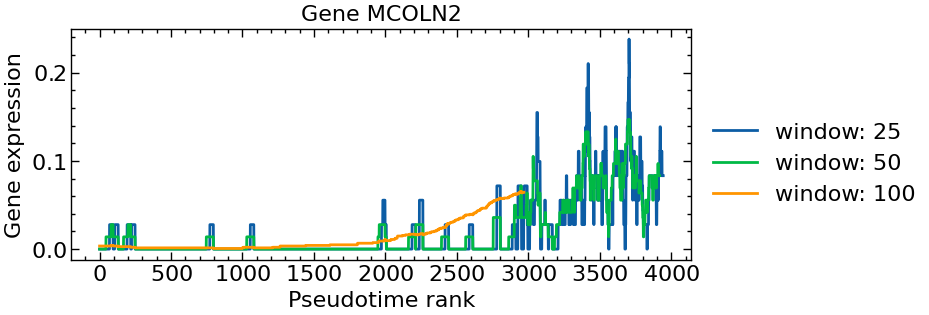

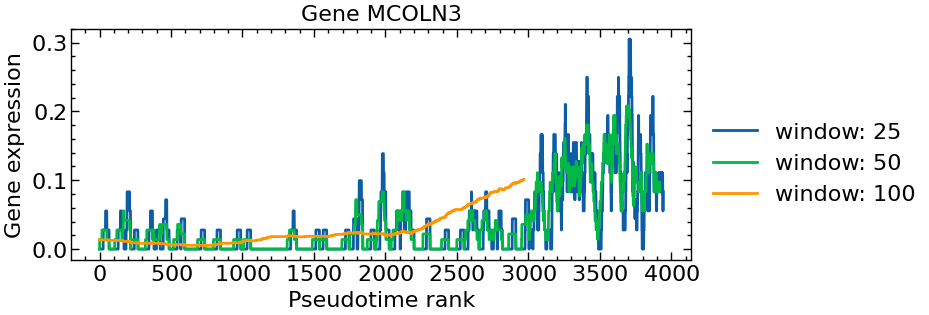

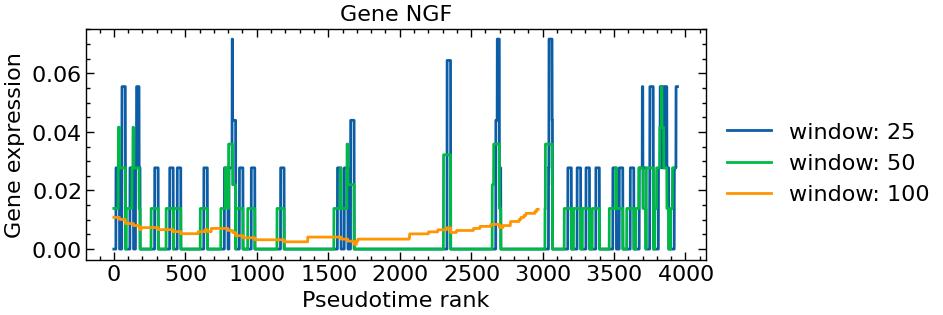

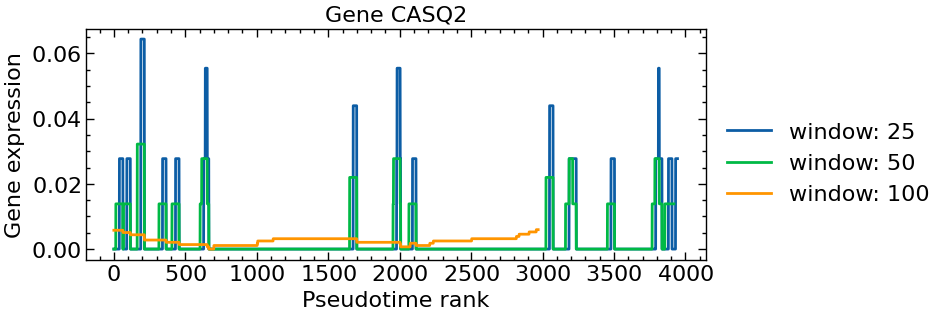

In [17]:
for i_gene in range(10):
    plt.figure(figsize=(8,3))
    #plt.plot(genes[:,i_gene], '-', label=f"Original")
    #plt.plot(moving_average(genes[:,i_gene], n=10), '-', label=f"window: 10")
    plt.plot(moving_average(genes[:,i_gene], n=30), '-', label=f"window: 30")
    plt.plot(moving_average(genes[:,i_gene], n=50), '-', label=f"window: 50")
    plt.plot(moving_average(genes[:,i_gene], n=100), '-', label=f"window: 100")
    plt.legend(loc=(1.02,0.20))
    plt.xlabel("Pseudotime rank")
    plt.ylabel("Gene expression")
    plt.title(f"Gene {genes_names[i_gene]}")
    plt.savefig(f"./figures/gene{i_gene}.pdf", dpi=300)
    plt.show()